# 1 Linear Regression Baseline

In this notebook, we load our preprocessed time-series data and train a Linear Regression model. This will serve as our baseline to establish how well standard autoregressive features (lags and rolling means) predict future electricity consumption.

## 1. Imports and Data Loading
We import pandas for data handling, and scikit-learn for our model, metrics, and data splitting. Then we load the highly compressed Parquet file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from tqdm import tqdm

# Load Data
print("Loading processed data...")
df_long = pd.read_parquet('../Datasets/processed_electricity_data.parquet')

Loading processed data...


### 2 Feature Engineering & Strict Data Splitting
Before standardizing, we encode our categorical variables (Hour, Weekday, Consumer Category) using one-hot encoding. 
To rigorously prevent **Data Leakage**, we split our dataset strictly chronologically: all data prior to 2014 is used for training, and all data from 2014 onwards is strictly reserved for testing.

In [ ]:
# Feature Engineering and Train/Test Split
df_long['Is_Weekend'] = df_long['Is_Weekend'].astype(int)
df_long['Is_Holiday'] = df_long['Is_Holiday'].astype(int)

df_model = pd.get_dummies(df_long, columns=['Hour', 'Weekday', 'Month', 'Consumer_Category'], drop_first=True)

train = df_model[df_model['Date'].dt.year < 2014].copy()
test  = df_model[df_model['Date'].dt.year >= 2014].copy()


# Per-Client Standardization
weather_cols = ['HDH', 'CDH']
scaler_weather = StandardScaler()
train[weather_cols] = scaler_weather.fit_transform(train[weather_cols])
test[weather_cols]  = scaler_weather.transform(test[weather_cols])

train = train.sort_values(by=['ClientID', 'Date'])
test  = test.sort_values(by=['ClientID', 'Date'])

for col in ['Lag_15min_Scaled', 'Lag_1h_Scaled', 'Lag_24h_Scaled', 'Lag_1week_Scaled', 'Rolling_Mean_4h_Scaled']:
    train[col] = np.nan
    test[col]  = np.nan

client_scalers = {}


# Since our clients have vastly different absolute consumption volumes (e.g., Light vs Heavy consumers), a single cluster model would be heavily biased towards large consumers. We apply `StandardScaler` to each client individually so the model learns the normalized patterns and shapes of consumption rather than the absolute magnitude. We apply this exact same scaler to the pre-computed lag features to keep all autoregressive inputs strictly on the same scale without breaking temporal continuity.
for client in tqdm(df_long['ClientID'].unique(), desc="Scaling Clients"):
    scaler = StandardScaler()
    train_mask = train['ClientID'] == client
    test_mask  = test['ClientID'] == client

    if not train_mask.any():
        print(f"Warning: Client {client} has no data in the train set. Skipping...")
        continue

    train.loc[train_mask, 'Consumption_Scaled'] = scaler.fit_transform(
        train.loc[train_mask, 'Consumption'].values.reshape(-1, 1)
    ).flatten()

    # We apply the SAME scaler fitted on Consumption to the historical lag columns to maintain the exact mathematical scale, without creating new NaNs with .shift()
    train.loc[train_mask, 'Lag_15min_Scaled'] = scaler.transform(train.loc[train_mask, 'Lag_15min'].values.reshape(-1, 1)).flatten()
    train.loc[train_mask, 'Lag_1h_Scaled'] = scaler.transform(train.loc[train_mask, 'Lag_1h'].values.reshape(-1, 1)).flatten()
    train.loc[train_mask, 'Lag_24h_Scaled'] = scaler.transform(train.loc[train_mask, 'Lag_24h'].values.reshape(-1, 1)).flatten()
    train.loc[train_mask, 'Lag_1week_Scaled'] = scaler.transform(train.loc[train_mask, 'Lag_1week'].values.reshape(-1, 1)).flatten()
    train.loc[train_mask, 'Rolling_Mean_4h_Scaled'] = scaler.transform(train.loc[train_mask, 'Rolling_Mean_4h'].values.reshape(-1, 1)).flatten()

    # We MUST scale the test set features as well, otherwise the model cannot predict
    if test_mask.any():
        test.loc[test_mask, 'Consumption_Scaled'] = scaler.transform(test.loc[test_mask, 'Consumption'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Lag_15min_Scaled'] = scaler.transform(test.loc[test_mask, 'Lag_15min'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Lag_1h_Scaled'] = scaler.transform(test.loc[test_mask, 'Lag_1h'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Lag_24h_Scaled'] = scaler.transform(test.loc[test_mask, 'Lag_24h'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Lag_1week_Scaled'] = scaler.transform(test.loc[test_mask, 'Lag_1week'].values.reshape(-1, 1)).flatten()
        test.loc[test_mask, 'Rolling_Mean_4h_Scaled'] = scaler.transform(test.loc[test_mask, 'Rolling_Mean_4h'].values.reshape(-1, 1)).flatten()

    client_scalers[client] = scaler

train = train.dropna(subset=['Consumption_Scaled', 'Lag_15min_Scaled', 'Lag_1h_Scaled', 'Lag_24h_Scaled', 'Lag_1week_Scaled', 'Rolling_Mean_4h_Scaled'])

# ---------------------------------------------------------
# Drop columns that should NOT be LR features
# Short-term lags dropped for Day-Ahead scenario (data leakage if used)
# Weather lags/anomalies excluded: these are for Prophet/SARIMAX only
# Temp_National_Avg excluded: multicollinear with HDH + CDH
# ---------------------------------------------------------
cols_to_drop = ['Date', 'ClientID', 'DayMonth', 'Consumption', 'Consumption_Scaled',
                'Lag_15min', 'Lag_1h', 'Lag_24h', 'Lag_1week', 'Rolling_Mean_4h',
                'Lag_15min_Scaled', 'Lag_1h_Scaled', 'Rolling_Mean_4h_Scaled',
                'Temp_National_Avg', 'HDH_lag24h', 'CDH_lag24h', 'HDH_anomaly', 'CDH_anomaly']

cols_to_drop = [c for c in cols_to_drop if c in train.columns]

X_train = train.drop(columns=cols_to_drop)
y_train = train['Consumption_Scaled']


test    = test.sort_values(by=['ClientID', 'Date'])
X_test  = test.drop(columns=cols_to_drop)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape:  {X_test.shape}")

## 3. Model Training and Evaluation
Rather than training 370 individual models (which is computationally expensive and prone to overfitting) or a single global model (which ignores unique behaviors), we instantiate **one Linear Regression model per behavioral cluster**. The model learns the overarching logic of its specific cluster (e.g., standard business hours vs. night shifts).

In [ ]:
# Dictionary to store the trained model for each cluster
cluster_models = {}

print("Training Linear Regression models per cluster...")

# We dropna() just in case any client didn't get mapped
unique_clusters = train['Cluster'].unique()

for cluster_id in sorted(unique_clusters):
    # Filter the rows belonging to the current cluster
    cluster_mask = train['Cluster'] == cluster_id

    # Create the cluster-specific feature matrix and target vector.
    # We drop 'Cluster' because it's an identifier, not a predictive numeric feature.
    X_train_cluster = X_train[cluster_mask].drop(columns=['Cluster'], errors='ignore')
    y_train_cluster = y_train[cluster_mask]

    # Initialize and fit the model for this entire cluster
    model = LinearRegression()
    model.fit(X_train_cluster.values, y_train_cluster)
    
    # Save the trained model in our dictionary
    cluster_models[cluster_id] = model
    
    print(f" - Model for Cluster {int(cluster_id)} trained on {len(X_train_cluster)} historical rows.")

Training Linear Regression models per cluster...
 - Model for Cluster 0 trained on 1907271 historical rows.
 - Model for Cluster 1 trained on 6918652 historical rows.
 - Model for Cluster 2 trained on 5144777 historical rows.


In [ ]:
print("Predicting on Test Set (Vectorized Day-Ahead)...")

# Initialize the predictions column with NaNs
test['Predicted_Consumption_Scaled'] = np.nan

# Fast vectorized prediction per Cluster
for cluster_id, model in cluster_models.items():
    # Find all rows in the test set belonging to the current cluster
    cluster_mask = test['Cluster'] == cluster_id
    
    # Prepare the feature matrix (X) by dropping the Cluster ID column
    X_test_cluster = X_test[cluster_mask].drop(columns=['Cluster'], errors='ignore')
    
    if len(X_test_cluster) > 0:
        # The prediction now strictly uses Lag_24h and Lag_1week 
        # (which are already pre-calculated in the test set, avoiding data leakage)
        preds = model.predict(X_test_cluster.values)
        test.loc[cluster_mask, 'Predicted_Consumption_Scaled'] = preds

print("Applying physical constraints (Capping at 0 kW)...")

# Custom 0 kW capping based on each client's individual scaler
for client in test['ClientID'].unique():
    if client in client_scalers:
        # Find the exact scaled value that corresponds to 0.0 kW for this specific client
        min_scaled_val = client_scalers[client].transform([[0.0]])[0][0]
        
        # Apply the floor limit (electricity consumption cannot be negative)
        c_mask = test['ClientID'] == client
        test.loc[c_mask, 'Predicted_Consumption_Scaled'] = np.maximum(
            test.loc[c_mask, 'Predicted_Consumption_Scaled'], 
            min_scaled_val
        )

print("Predictions Complete!")

Predicting on Test Set (Vectorized Day-Ahead)...
Applying physical constraints (Capping at 0 kW)...
Predictions Complete!


## 4 Model Evaluation (MAPE)
We inverse-transform our predictions back to raw kilowatts (kW) to evaluate true business performance. 
*Note on MAPE calculation:* Since electricity consumption occasionally drops to near-zero (e.g., outages, disconnections), calculating a standard MAPE causes extreme division-by-zero errors (resulting in astronomically high percentages). We strategically filter out values close to zero (`> 0.1 kW`) to report a robust, realistic MAPE strictly on a 0-100 scale, as requested.

In [ ]:
# Evaluation in raw kW (inverse-transform per client)
print("\nEvaluating model (raw kW)...")

all_mapes_kw  = []
client_results = []

for client in test['ClientID'].unique():
    if client not in client_scalers:
        continue
    
    client_mask = test['ClientID'] == client
    client_data = test[client_mask].copy()
    
    valid = client_data['Consumption'].notna() & client_data['Predicted_Consumption_Scaled'].notna()
    if valid.sum() == 0:
        continue

    y_true_kw = client_data.loc[valid, 'Consumption'].values
    
    scaler = client_scalers[client]
    y_pred_kw = scaler.inverse_transform(
        client_data.loc[valid, 'Predicted_Consumption_Scaled'].values.reshape(-1, 1)
    ).flatten()
    
    # Floor to zero (electricity consumption cannot be negative)
    y_pred_kw = np.maximum(y_pred_kw, 0)

    # Save the kW values 
    test.loc[client_data.index[valid], 'Actual_kW'] = y_true_kw
    test.loc[client_data.index[valid], 'Predicted_kW'] = y_pred_kw


# Sum the Actual and Predicted consumption by Cluster and Hour (Date)
cluster_eval = test.dropna(subset=['Actual_kW', 'Predicted_kW']).groupby(['Cluster', 'Date'], observed=True)[['Actual_kW', 'Predicted_kW']].sum().reset_index()

# Calculate the absolute and percentage error on the aggregated hourly consumption
cluster_eval['Abs_Error'] = np.abs(cluster_eval['Actual_kW'] - cluster_eval['Predicted_kW'])

# For the aggregated MAPE, filter out the rare cases of zero aggregated consumption to avoid infinity
mask_mape = cluster_eval['Actual_kW'] > 0.1
cluster_eval.loc[mask_mape, 'Perc_Error'] = (cluster_eval['Abs_Error'] / cluster_eval['Actual_kW']) * 100

print("\n--- LINEAR REGRESSION PERFORMANCE BY CLUSTER (BUSINESS ORIENTED) ---\n")

# Calculate true WMAPE and MAPE for each Cluster
summary = cluster_eval.groupby('Cluster', observed=True).agg(
    Portfolio_MAPE=('Perc_Error', 'mean'),
    Total_Abs_Error=('Abs_Error', 'sum'),
    Total_Actual=('Actual_kW', 'sum')
)

summary['Portfolio_WMAPE'] = (summary['Total_Abs_Error'] / summary['Total_Actual']) * 100
summary = summary.drop(columns=['Total_Abs_Error', 'Total_Actual']).round(2)

print(summary)

# Global WMAPE and MAPE (Entire Portfolio / Company Level)
global_wmape = (cluster_eval['Abs_Error'].sum() / cluster_eval['Actual_kW'].sum()) * 100
global_mape = cluster_eval['Perc_Error'].mean()
print(f"\nGlobal Portfolio MAPE: {global_mape:.2f}%")
print(f"Global Portfolio WMAPE: {global_wmape:.2f}%")


Evaluating model (raw kW)...

--- AGGREGATING FORECASTS AT CLUSTER LEVEL (PORTFOLIO EFFECT) ---

--- LINEAR REGRESSION PERFORMANCE BY CLUSTER (BUSINESS ORIENTED) ---

         Portfolio_MAPE  Portfolio_WMAPE
Cluster                                 
0.0              177.25             3.50
1.0               12.70             5.71
2.0               46.01             4.30
3.0                5.30             3.52
4.0               13.44            11.30

Global Portfolio MAPE: 50.94%
Global Portfolio WMAPE: 5.36%


## 5 Forecasting Visualization
To visually validate our model, we plot the actual vs. predicted consumption for one representative client per cluster. 
Since plotting a full year of 15-minute intervals produces an unreadable graph, we deliberately slice the data to show only the **last 14 days** of the test set. This provides a clear, high-resolution view of how well the autoregressive model captures daily seasonality.

Generating Cluster Portfolio visualizations...


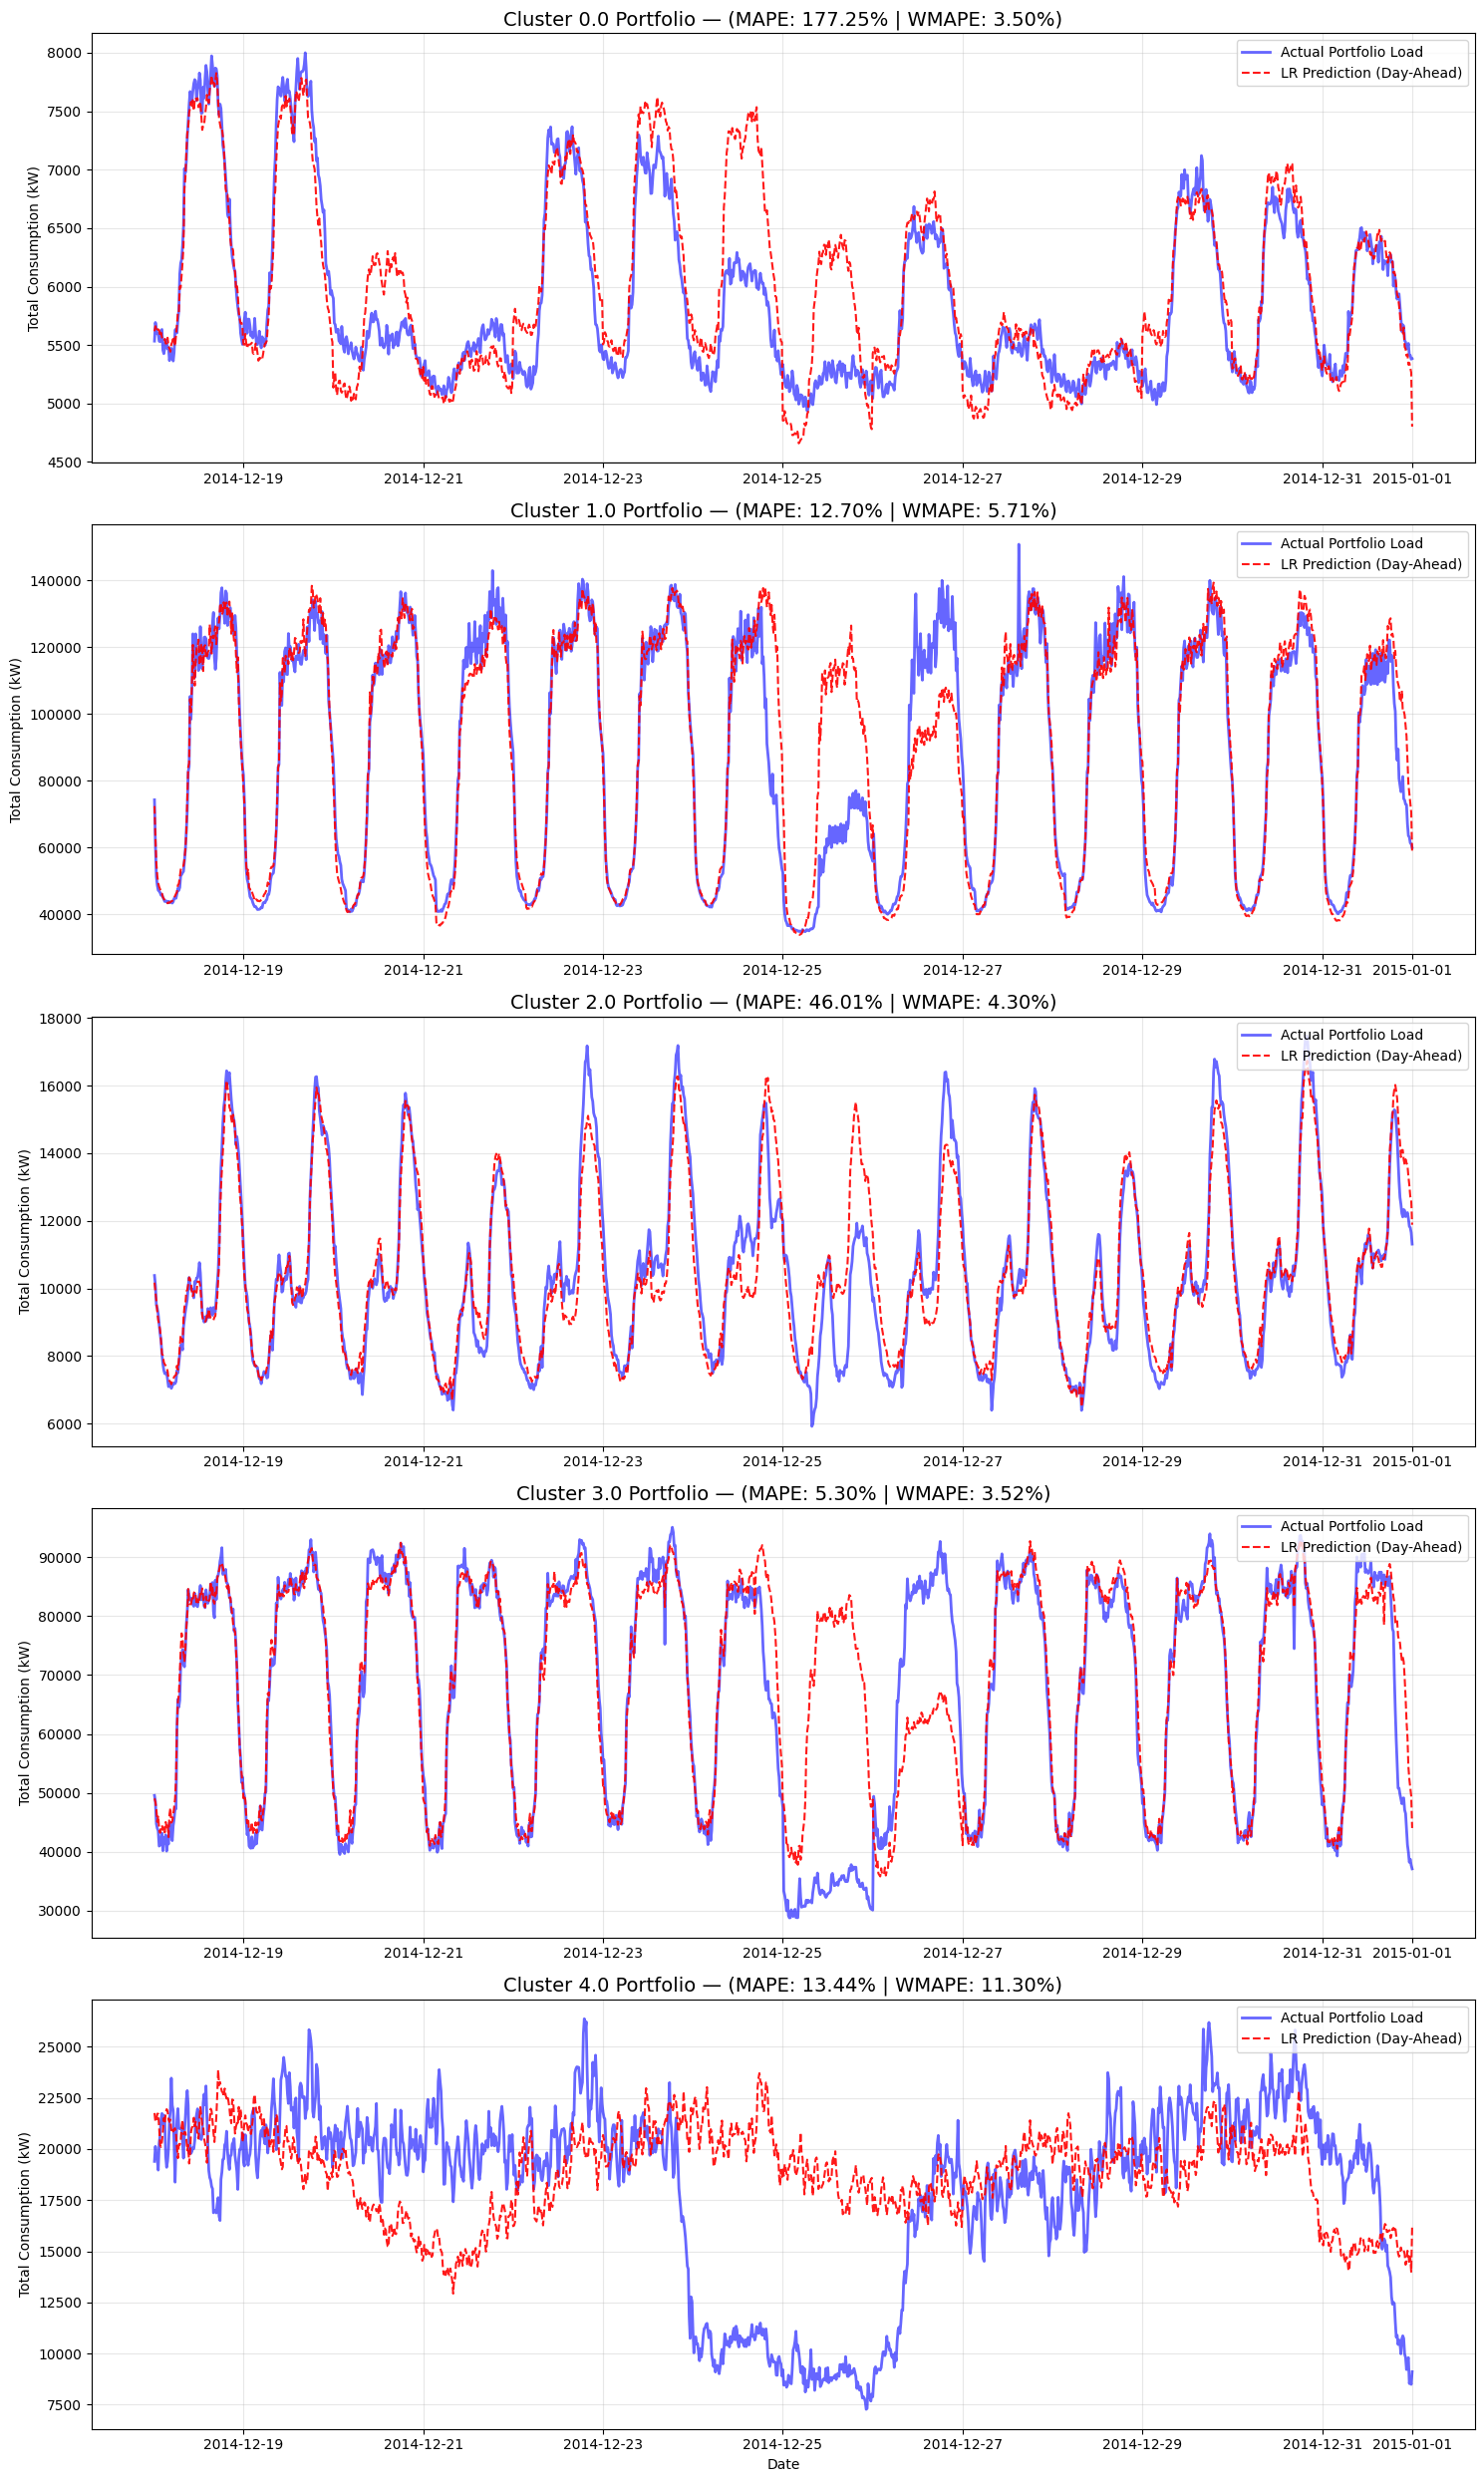

In [ ]:
# --- Visualization: Aggregated Cluster Portfolio (Last 2 Weeks) ---
print("Generating Cluster Portfolio visualizations...")

# Get unique clusters from our evaluation dataframe
unique_clusters = sorted(cluster_eval['Cluster'].unique())

fig, axes = plt.subplots(len(unique_clusters), 1, figsize=(15, 5 * len(unique_clusters)))

# Ensure axes is an array even if there is only 1 cluster
if len(unique_clusters) == 1:
    axes = [axes]

for idx, cluster_id in enumerate(unique_clusters):
    ax = axes[idx]
    
    # Filter data for the specific cluster
    c_plot = cluster_eval[cluster_eval['Cluster'] == cluster_id].sort_values('Date')
    
    # Get the Portfolio MAPE for the title (from the 'summary' dataframe we created earlier)
    c_mape = summary.loc[cluster_id, 'Portfolio_MAPE']
    c_wmape = summary.loc[cluster_id, 'Portfolio_WMAPE']

    # Slice to plot only the last 2 weeks (14 days * 96 steps = 1344)
    # This provides a clear view of the model's ability to follow daily/weekly cycles
    plot_slice = -1344 
    
    ax.plot(c_plot['Date'].values[plot_slice:], c_plot['Actual_kW'].values[plot_slice:],
            label='Actual Portfolio Load', color='blue', alpha=0.6, linewidth=2)
    ax.plot(c_plot['Date'].values[plot_slice:], c_plot['Predicted_kW'].values[plot_slice:],
            label='LR Prediction (Day-Ahead)', color='red', linestyle='--', alpha=0.9, linewidth=1.5)

    ax.set_title(f'Cluster {cluster_id} Portfolio — (MAPE: {c_mape:.2f}% | WMAPE: {c_wmape:.2f}%)', fontsize=14)
    ax.set_ylabel('Total Consumption (kW)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 6. Testing Results: Time Period Analysis & Error Box Plots
To evaluate the temporal stability of our models, we divide the testing dataset chronologically into 4 equal periods (quantiles). 

For each period, we report the global MAPE and visualize the spread of the Absolute Percentage Error (APE) using box plots. This helps us identify periods of high variance or deteriorating model performance over time. *(Note: Outliers are hidden in the box plot for visual clarity, as dividing by very small actual consumption values can create extreme percentage spikes).*

Preparing data for Time Period Analysis...

--- PORTFOLIO PERFORMANCE BY TIME PERIOD (Aggregated) ---
Dec 31 to Apr 02:   WMAPE = 3.93% | MAPE = 16.98%
Apr 02 to Jul 02:   WMAPE = 3.98% | MAPE = 3.85%
Jul 02 to Oct 01:   WMAPE = 3.42% | MAPE = 3.38%
Oct 01 to Jan 01:   WMAPE = 4.32% | MAPE = 4.64%


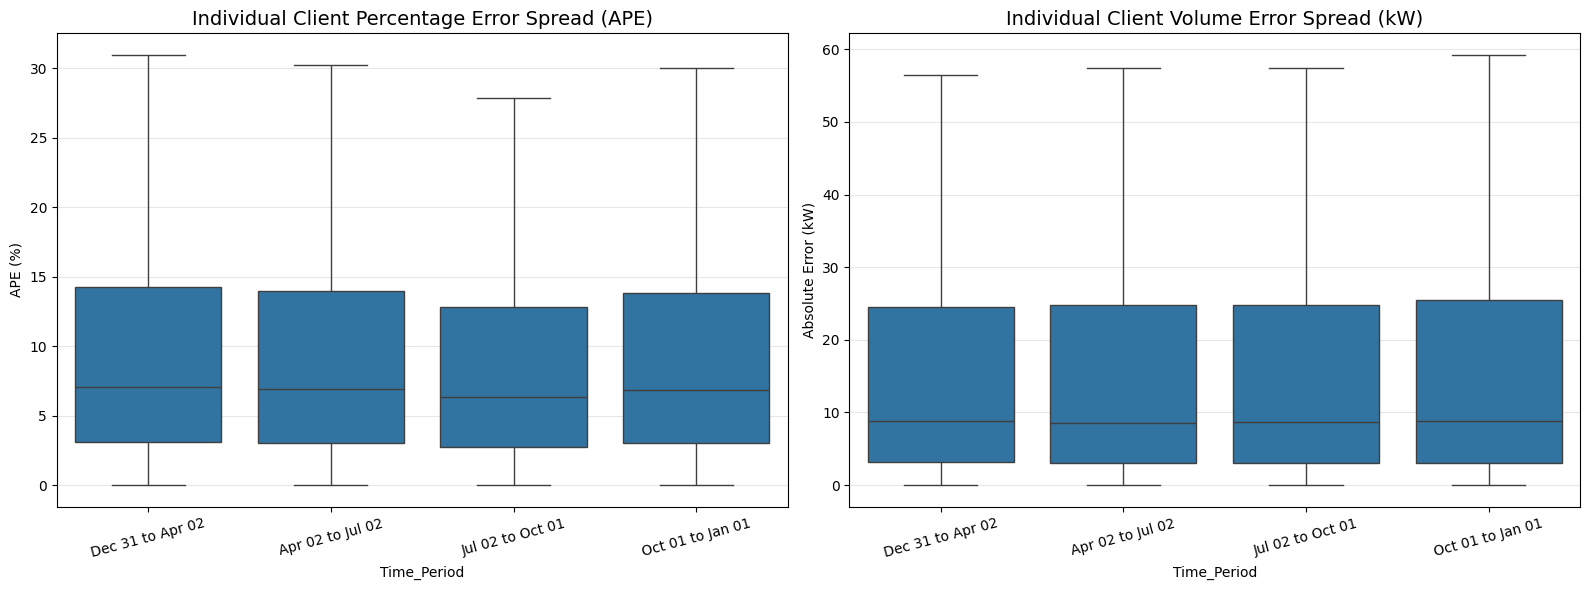

In [ ]:
# --- TIME PERIOD ANALYSIS & ERROR SPREAD ---
print("Preparing data for Time Period Analysis...")

# Create the evaluation dataframe using the raw kW columns already calculated
# This includes all individual client rows
df_eval = test.dropna(subset=['Actual_kW', 'Predicted_kW']).copy()

# Sort chronologically to ensure time periods are contiguous for binning
df_eval = df_eval.sort_values('Date')

# --- DYNAMIC TIME PERIOD LABELS ---
# Define 4 equal time windows across the test set duration
_, bin_edges = pd.cut(df_eval['Date'], bins=4, retbins=True)
bin_edges = pd.to_datetime(bin_edges)
dynamic_labels = [f"{bin_edges[i].strftime('%b %d')} to {bin_edges[i+1].strftime('%b %d')}" for i in range(4)]

# Apply the time period labels to the individual rows
df_eval['Time_Period'] = pd.cut(df_eval['Date'], bins=4, labels=dynamic_labels)

# --- PORTFOLIO-LEVEL ANALYSIS (Business Perspective) ---
# We aggregate all clients by timestamp to calculate the error of the entire portfolio
portfolio_ts = df_eval.groupby(['Date', 'Time_Period'], observed=True)[['Actual_kW', 'Predicted_kW']].sum().reset_index()

# Calculate Absolute Error and APE for the aggregated hourly load
portfolio_ts['Abs_Error'] = np.abs(portfolio_ts['Actual_kW'] - portfolio_ts['Predicted_kW'])
portfolio_ts['APE'] = (portfolio_ts['Abs_Error'] / portfolio_ts['Actual_kW']) * 100

print("\n--- PORTFOLIO PERFORMANCE BY TIME PERIOD (Aggregated) ---")
# Portfolio WMAPE: Total Absolute Error / Total Actual Load within each period
portfolio_wmape = portfolio_ts.groupby('Time_Period', observed=True).apply(
    lambda x: (x['Abs_Error'].sum() / x['Actual_kW'].sum()) * 100
)

for period, wmape_val in portfolio_wmape.items():
    avg_mape = portfolio_ts[portfolio_ts['Time_Period'] == period]['APE'].mean()
    print(f"{period}:   WMAPE = {wmape_val:.2f}% | MAPE = {avg_mape:.2f}%")


# --- INDIVIDUAL CLIENT SPREAD ANALYSIS (Risk Perspective) ---
# We look at the row-by-row Absolute Error to see how much variance exists between clients
df_eval['Abs_Error'] = np.abs(df_eval['Actual_kW'] - df_eval['Predicted_kW'])

# Calculate APE for individual rows (filtering near-zero consumption to avoid infinity)
mask_ape = df_eval['Actual_kW'] > 0.1
df_ape = df_eval[mask_ape].copy()
df_ape['APE'] = (df_ape['Abs_Error'] / df_ape['Actual_kW']) * 100

# Visualizing the distribution of errors across time periods
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Spread of Percentage Errors (APE) per individual client record
sns.boxplot(data=df_ape, x='Time_Period', y='APE', ax=axes[0], showfliers=False)
axes[0].set_title('Individual Client Percentage Error Spread (APE)', fontsize=14)
axes[0].set_ylabel('APE (%)')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=15)

# Plot 2: Spread of Absolute Volume Errors (kW) per individual client record
sns.boxplot(data=df_eval, x='Time_Period', y='Abs_Error', ax=axes[1], showfliers=False)
axes[1].set_title('Individual Client Volume Error Spread (kW)', fontsize=14)
axes[1].set_ylabel('Absolute Error (kW)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()